In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
df


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140.4 KB


In [ ]:
df.describe()


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [ ]:
duplicate = df.duplicated().sum()

duplicate


np.int64(0)

In [ ]:
df.isnull().sum()


age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [ ]:
df.sample(20)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
159,13,male,7.5,Both,8.0,2.0,3.25,0.7,medium,9,10,2,0
186,15,female,3.5,Instagram,6.3,0.8,2.71,1.8,high,7,4,2,0
1053,19,female,7.6,Both,5.4,1.9,2.56,1.4,low,2,7,9,0
485,14,male,3.9,Instagram,7.7,1.4,2.86,1.7,high,3,5,1,0
1134,18,female,5.3,Both,4.6,1.5,2.54,0.6,medium,4,3,4,0
214,13,male,5.9,Instagram,7.5,1.4,2.58,1.2,low,6,2,8,0
41,19,male,1.6,Instagram,8.6,2.4,3.81,0.4,low,10,4,1,0
701,18,female,3.8,Instagram,5.9,1.0,2.22,0.6,low,9,10,9,0
990,19,female,7.2,Instagram,6.4,2.9,3.82,1.0,medium,5,4,5,0
26,14,female,5.7,Both,8.7,0.6,2.64,0.1,low,8,9,4,0


<Axes: xlabel='depression_label'>

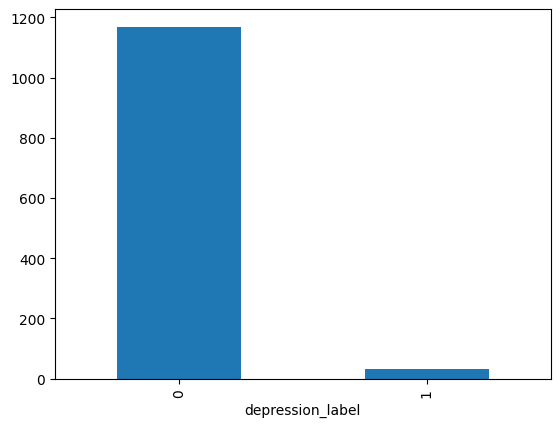

In [ ]:
df['depression_label'].value_counts()
df['depression_label'].value_counts().plot(kind='bar')


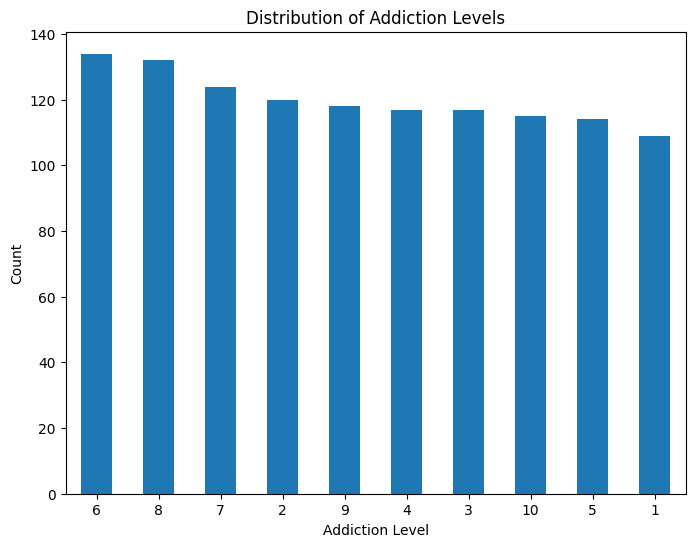

In [ ]:
plt.figure(figsize=(8, 6))

df['addiction_level'].value_counts().plot(kind='bar')
plt.xlabel('Addiction Level')
plt.ylabel('Count')
plt.title('Distribution of Addiction Levels')
plt.xticks(rotation=0)
plt.show()


In [ ]:
df.corr(numeric_only=True)


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265,0.010973
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964,0.175201
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838,-0.190630
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884,-0.016502
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354,0.001441
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200,-0.017598
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129,0.170474
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154,0.169566
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000,-0.013952
depression_label,0.010973,0.175201,-0.190630,-0.016502,0.001441,-0.017598,0.170474,0.169566,-0.013952,1.000000


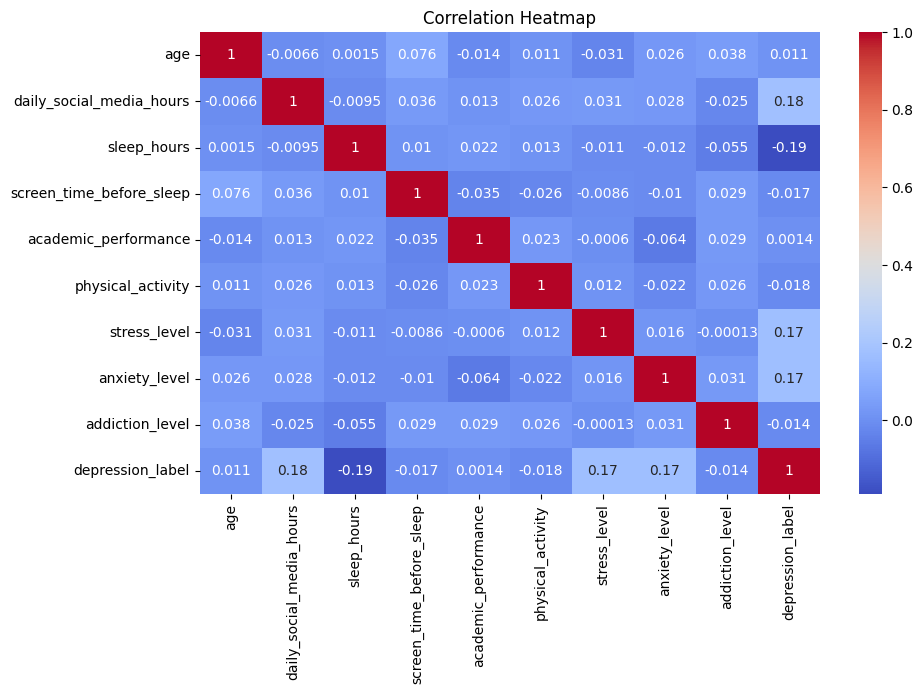

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Text(0.5, 1.0, 'Distribution of Platform Usage')

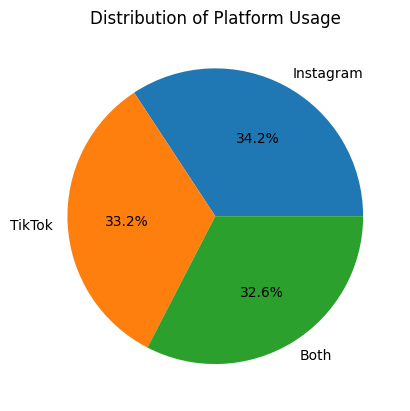

In [ ]:
plt.pie(df['platform_usage'].value_counts(),
        labels=df['platform_usage'].value_counts().index, autopct='%1.1f%%')
plt.title('Distribution of Platform Usage')


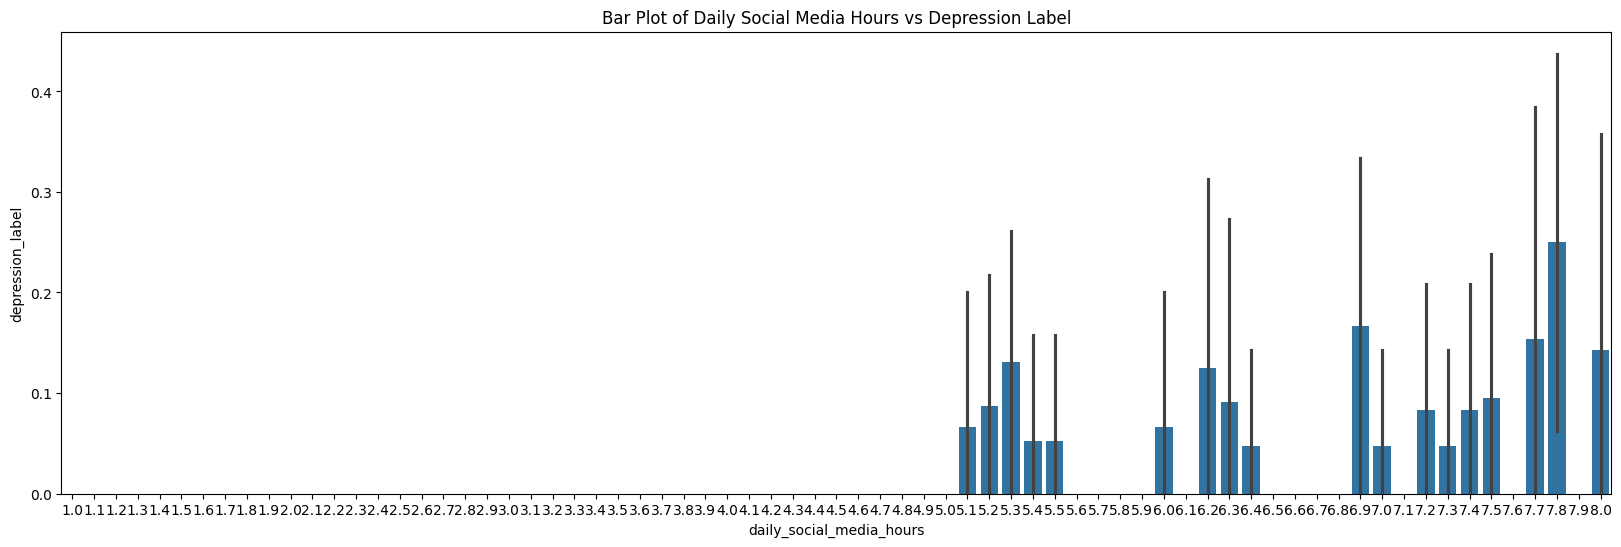

In [ ]:
plt.figure(figsize=(20, 6))
sns.barplot(x='daily_social_media_hours', y='depression_label', data=df)
plt.title('Bar Plot of Daily Social Media Hours vs Depression Label')
plt.xticks(rotation=0)
plt.show()


In [ ]:
# Count the number of rows where gender is 'female'
(df['gender'] == 'female').sum()


np.int64(585)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['gender'] = label_encoder.fit_transform(df['gender'])

df['gender'].value_counts()


gender
1    615
0    585
Name: count, dtype: int64

In [ ]:
df


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,0,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,0,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,1,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,0,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,0,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,1,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,0,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,1,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['platform_usage'] = label_encoder.fit_transform(df['platform_usage'])
df['platform_usage'].value_counts()


platform_usage
1    411
2    398
0    391
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['social_interaction_level'] = label_encoder.fit_transform(
    df['social_interaction_level'])
df['social_interaction_level'].value_counts()


social_interaction_level
2    416
1    415
0    369
Name: count, dtype: int64

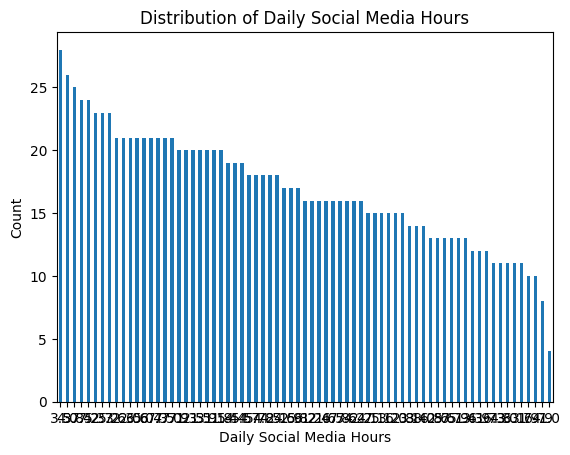

In [ ]:
df['daily_social_media_hours'].value_counts().plot(kind='bar')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Count')
plt.title('Distribution of Daily Social Media Hours')
plt.xticks(rotation=0)
plt.show()


In [ ]:
df['academic_performance'].value_counts()


academic_performance
2.36    13
3.90    13
2.84    12
2.29    12
2.91    12
        ..
3.37     2
3.78     2
3.23     2
3.95     1
3.02     1
Name: count, Length: 201, dtype: int64

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numeric_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'social_interaction_level', 'screen_time_before_sleep',
                'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']
df_scaled = df.copy()
df_scaled[['daily_social_media_hours']] = scaler.fit_transform(
    df[['daily_social_media_hours']])
df_scaled[['age']] = scaler.fit_transform(df[['age']])
df_scaled[['sleep_hours']] = scaler.fit_transform(df[['sleep_hours']])
df_scaled[['social_interaction_level']] = scaler.fit_transform(
    df[['social_interaction_level']])
df_scaled[['screen_time_before_sleep']] = scaler.fit_transform(
    df[['screen_time_before_sleep']])
df_scaled[['academic_performance']] = scaler.fit_transform(
    df[['academic_performance']])
df_scaled[['physical_activity']] = scaler.fit_transform(
    df[['physical_activity']])
df_scaled[['stress_level']] = scaler.fit_transform(df[['stress_level']])
df_scaled[['anxiety_level']] = scaler.fit_transform(df[['anxiety_level']])
df_scaled[['addiction_level']] = scaler.fit_transform(df[['addiction_level']])

df_scaled.head()


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,0.166667,1,0.985714,1,0.68,0.96,0.505,0.75,0.5,0.111111,0.111111,0.000000,0
1,1.000000,0,0.128571,2,0.80,0.96,0.610,0.40,0.0,0.777778,0.000000,1.000000,0
2,0.666667,0,0.042857,1,0.72,0.00,0.960,0.00,0.0,0.111111,0.333333,0.111111,0
3,0.333333,1,0.914286,2,0.58,0.44,0.740,0.40,1.0,0.000000,0.666667,0.888889,0
4,0.333333,0,0.528571,0,0.18,1.00,0.185,0.70,1.0,0.222222,0.444444,0.111111,0


In [ ]:
df_scaled


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,0.166667,1,0.985714,1,0.68,0.96,0.505,0.75,0.5,0.111111,0.111111,0.000000,0
1,1.000000,0,0.128571,2,0.80,0.96,0.610,0.40,0.0,0.777778,0.000000,1.000000,0
2,0.666667,0,0.042857,1,0.72,0.00,0.960,0.00,0.0,0.111111,0.333333,0.111111,0
3,0.333333,1,0.914286,2,0.58,0.44,0.740,0.40,1.0,0.000000,0.666667,0.888889,0
4,0.333333,0,0.528571,0,0.18,1.00,0.185,0.70,1.0,0.222222,0.444444,0.111111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,0.833333,0,0.828571,1,0.52,0.60,0.380,0.50,0.5,0.222222,0.333333,0.333333,0
1196,0.500000,1,0.185714,0,0.80,0.56,0.060,0.20,0.0,0.666667,0.333333,0.333333,0
1197,0.166667,0,0.100000,0,0.94,0.08,0.990,0.40,0.0,0.000000,0.000000,0.000000,0
1198,0.333333,1,0.414286,0,0.90,0.64,0.595,0.30,0.0,0.666667,0.888889,0.888889,0


In [ ]:
df_scaled


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,0.166667,1,0.985714,1,0.68,0.96,0.505,0.75,0.5,0.111111,0.111111,0.000000,0
1,1.000000,0,0.128571,2,0.80,0.96,0.610,0.40,0.0,0.777778,0.000000,1.000000,0
2,0.666667,0,0.042857,1,0.72,0.00,0.960,0.00,0.0,0.111111,0.333333,0.111111,0
3,0.333333,1,0.914286,2,0.58,0.44,0.740,0.40,1.0,0.000000,0.666667,0.888889,0
4,0.333333,0,0.528571,0,0.18,1.00,0.185,0.70,1.0,0.222222,0.444444,0.111111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,0.833333,0,0.828571,1,0.52,0.60,0.380,0.50,0.5,0.222222,0.333333,0.333333,0
1196,0.500000,1,0.185714,0,0.80,0.56,0.060,0.20,0.0,0.666667,0.333333,0.333333,0
1197,0.166667,0,0.100000,0,0.94,0.08,0.990,0.40,0.0,0.000000,0.000000,0.000000,0
1198,0.333333,1,0.414286,0,0.90,0.64,0.595,0.30,0.0,0.666667,0.888889,0.888889,0


In [ ]:
X = df_scaled.drop('depression_label', axis=1)
Y = df_scaled['depression_label']


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. Split data FIRST (to keep test set pure)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42)

# 2. Initialize SMOTE
smote = SMOTE(random_state=42)

# 3. Fit and Resample the training data
X_train_res, Y_train_res = smote.fit_resample(X_train, Y_train)

# Now use X_train_res and Y_train_res to train your model


In [ ]:
X_train


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
535,0.000000,1,0.171429,0,0.36,0.60,0.815,0.95,0.5,0.333333,0.333333,1.000000
462,0.000000,1,0.985714,2,0.40,0.88,0.425,0.15,0.5,0.888889,1.000000,0.222222
605,0.500000,0,0.600000,2,0.82,0.64,0.335,0.85,1.0,0.888889,1.000000,1.000000
8,1.000000,0,0.328571,2,0.20,0.64,0.020,0.45,0.0,0.000000,1.000000,0.888889
35,0.666667,0,0.571429,0,0.18,0.64,0.005,0.50,0.5,0.888889,0.333333,0.888889
...,...,...,...,...,...,...,...,...,...,...,...,...
720,0.166667,1,0.314286,1,0.28,0.84,0.590,0.45,0.5,0.888889,0.000000,0.666667
840,0.666667,1,0.400000,1,0.74,0.08,0.725,0.50,0.5,0.111111,0.777778,0.888889
510,0.166667,1,0.642857,2,0.68,0.96,0.770,0.55,0.0,0.777778,0.333333,1.000000
1125,0.166667,0,0.671429,1,0.54,0.84,0.175,0.90,0.0,1.000000,1.000000,0.666667


In [ ]:
Y_train_res.value_counts()


depression_label
0    935
1    935
Name: count, dtype: int64

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_reg = LogisticRegression()
log_reg.fit(X_train_res, Y_train_res)
y_pred = log_reg.predict(X_test)
print(classification_report(Y_test, y_pred))
print(confusion_matrix(Y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.97      0.98       234
           1       0.43      1.00      0.60         6

    accuracy                           0.97       240
   macro avg       0.71      0.98      0.79       240
weighted avg       0.99      0.97      0.97       240

[[226   8]
 [  0   6]]


In [ ]:
print(confusion_matrix(Y_test, y_pred))


array([[226,   8],
       [  0,   6]])

Text(0.5, 36.72222222222221, 'Predicted')

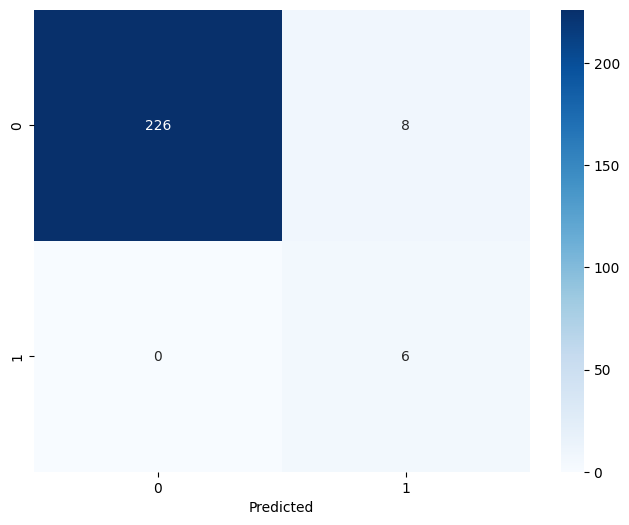

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(Y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')


In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
accuracy = accuracy_score(Y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(Y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')


Accuracy: 0.9667
Balanced Accuracy: 0.9829


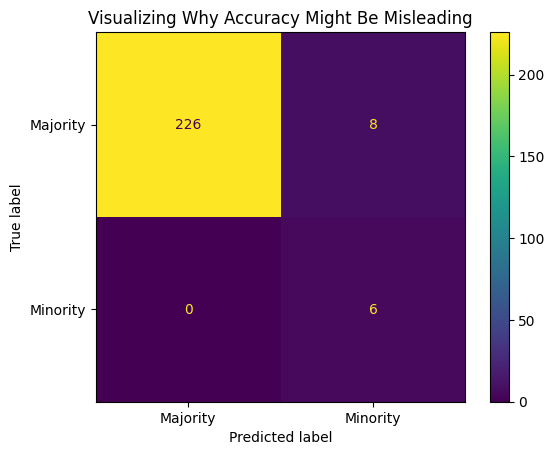

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plotting the matrix to visualize the split
ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred, display_labels=['Majority', 'Minority'])
plt.title("Visualizing Why Accuracy Might Be Misleading")
plt.show()
